In [3]:
# ── Setup: config + imports ──────────────────────────────────────────────────
import glob
import os
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator

# ── Config (mirrors crop_airs.ipynb) ─────────────────────────────────────────
CROP_OUT_DIR = r"D:\COCCON\Work\Data\AIRS-cropped"
VARNAME      = "co_mmr_midtrop"
MW_RATIO     = 28.01 / 44.01          # CO / CO2 molar-mass conversion
OUT_DIR      = r"D:\COCCON\Work\Figures"
os.makedirs(OUT_DIR, exist_ok=True)

# Restrict to a balanced window: Jan 2003 – Dec 2025 (23 whole years)
START_TS = pd.Timestamp("2003-01-01")
END_TS   = pd.Timestamp("2025-12-01")


In [4]:
# ── Build COMPLETE monthly MAPS, then the spatial-mean time series ───────────
# Strategy (what you asked for): reconstruct the *grid maps* for missing months
# first — interpolate each pixel in time across the full calendar — then take
# the spatial mean of every (reconstructed) map to form the time series. So an
# interpolated month's mean is the mean of a real interpolated map, consistent
# with the per-pixel trend cell later. No 12-month rolling mean.
crop_files = sorted(glob.glob(os.path.join(CROP_OUT_DIR, "*.nc")))
print(f"Found {len(crop_files)} cropped files")

# -- load each existing month's (lat, lon) map, keyed by date ------------------
maps_by_date = {}
lons_g = lats_g = None
for f in crop_files:
    stem = os.path.splitext(os.path.basename(f))[0]          # "202301"
    date = pd.Timestamp(f"{stem[:4]}-{stem[4:]}-01")
    if not (START_TS <= date <= END_TS):                     # balanced window
        continue
    ds_g = xr.open_dataset(f, decode_timedelta=False)
    if lons_g is None:
        lons_g = ds_g["lon"].values
        lats_g = ds_g["lat"].values
    maps_by_date[date] = ds_g[VARNAME].mean(dim="orbit_pass", skipna=True).values * MW_RATIO
    ds_g.close()

n_lat, n_lon = len(lats_g), len(lons_g)

# -- full monthly calendar Jan 2003 – Dec 2025 (276 months) -------------------
full_index = pd.date_range(START_TS, END_TS, freq="MS")

# -- stack into a (time, lat, lon) cube; entirely-missing months are all-NaN ---
cube_raw = np.full((len(full_index), n_lat, n_lon), np.nan)
present_mask = np.zeros(len(full_index), dtype=bool)         # month-level: map exists
for i, d in enumerate(full_index):
    if d in maps_by_date:
        cube_raw[i] = maps_by_date[d]
        present_mask[i] = True
interp_mask = ~present_mask                                  # months we must reconstruct

# -- interpolate the MAPS in time, per pixel (reconstruct missing grids) -------
cube_da = xr.DataArray(
    cube_raw, dims=("time", "lat", "lon"),
    coords={"time": full_index, "lat": lats_g, "lon": lons_g},
)
cube_da = (cube_da.interpolate_na(dim="time", method="linear")
                  .bfill("time").ffill("time"))             # also cover edge gaps

# -- time series = spatial mean of each (reconstructed) map --------------------
ts_dates = full_index
ts_co    = cube_da.mean(dim=("lat", "lon"), skipna=True).values

# ── interpolation results / diagnostics (reported right here) ────────────────
n_pix       = n_lat * n_lon
filled_dates = [d.strftime('%Y-%m') for d in full_index[interp_mask]]
# how many pixels each reconstructed map actually filled (vs. originally NaN)
print("── Map interpolation ──────────────────────────────────────────────")
print(f"Calendar months   : {len(full_index)}   (Jan 2003 – Dec 2025)")
print(f"Observed maps      : {present_mask.sum()}")
print(f"Reconstructed maps : {interp_mask.sum()}  -> {filled_dates}")
print(f"Grid per map       : {n_lat} lat × {n_lon} lon = {n_pix} pixels")
for i in np.where(interp_mask)[0]:
    n_valid_orig = int(np.isfinite(cube_raw[i]).sum())       # 0 for a fully-missing month
    n_valid_new  = int(np.isfinite(cube_da.values[i]).sum())
    print(f"   {full_index[i].strftime('%Y-%m')}: filled {n_valid_new - n_valid_orig} "
          f"pixels  ->  map mean = {ts_co[i]:.4e} kg/kg")

# residual NaNs (pixels never observed in ANY month) — excluded from the mean
n_dead = int(np.isnan(cube_da.values).all(axis=0).sum())
print(f"Pixels never observed (left NaN): {n_dead}")
print(f"Date range : {ts_dates[0].date()}  ->  {ts_dates[-1].date()}")
print(f"CO range   : {np.nanmin(ts_co):.4e} – {np.nanmax(ts_co):.4e}  kg/kg")


Found 279 cropped files
── Map interpolation ──────────────────────────────────────────────
Calendar months   : 276   (Jan 2003 – Dec 2025)
Observed maps      : 274
Reconstructed maps : 2  -> ['2023-09', '2025-12']
Grid per map       : 36 lat × 61 lon = 2196 pixels
   2023-09: filled 2196 pixels  ->  map mean = 8.5295e-08 kg/kg
   2025-12: filled 2196 pixels  ->  map mean = 7.6991e-08 kg/kg
Pixels never observed (left NaN): 0
Date range : 2003-01-01  ->  2025-12-01
CO range   : 7.6991e-08 – 1.1788e-07  kg/kg


In [5]:
# ── Simple linear regression  y = a*x + b  ───────────────────────────────────
# x is time expressed in years since the first sample (so the slope reads as
# "kg/kg per year"). We fit with np.polyfit and recover parameter errors from
# the covariance matrix.

# numeric x: years elapsed since the first date
x = (ts_dates - ts_dates[0]).days.values / 365.25      # decimal years
y = ts_co

# drop any NaNs just in case
good = np.isfinite(x) & np.isfinite(y)
x, y = x[good], y[good]
n = len(x)

# least-squares fit with covariance estimate
coeffs, cov = np.polyfit(x, y, 1, cov=True)
a, b = coeffs                      # a = slope, b = intercept
a_err, b_err = np.sqrt(np.diag(cov))

# goodness-of-fit extras
y_fit   = a * x + b
resid   = y - y_fit
ss_res  = np.sum(resid**2)
ss_tot  = np.sum((y - y.mean())**2)
r2      = 1 - ss_res / ss_tot
rmse    = np.sqrt(ss_res / n)

print("Linear regression  y = a*x + b   (x in years since "
      f"{ts_dates[0].date()})")
print("-" * 60)
print(f"  slope a     = {a:.6e}  +/- {a_err:.2e}  kg/kg per year")
print(f"  intercept b = {b:.6e}  +/- {b_err:.2e}  kg/kg")
print(f"  R^2         = {r2:.4f}")
print(f"  RMSE        = {rmse:.4e}  kg/kg")
print(f"  N points    = {n}")


Linear regression  y = a*x + b   (x in years since 2003-01-01)
------------------------------------------------------------
  slope a     = -4.735434e-10  +/- 7.57e-11  kg/kg per year
  intercept b = 9.575737e-08  +/- 1.00e-09  kg/kg
  R^2         = 0.1249
  RMSE        = 8.3210e-09  kg/kg
  N points    = 276


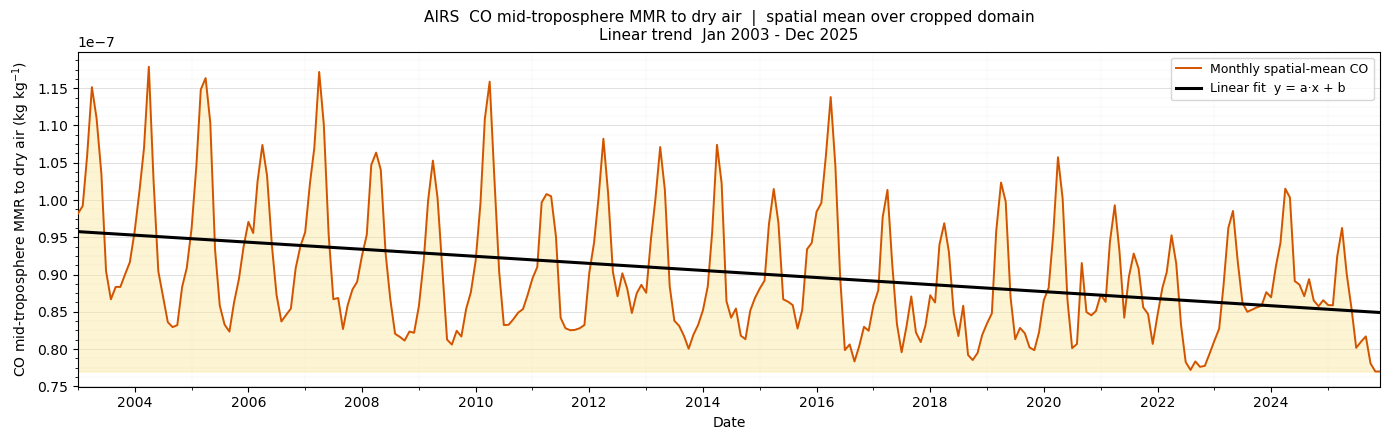

Saved -> D:\COCCON\Work\Figures\timeseries_co_linear_trend_2003_2025.png


In [6]:
# ── Plot: time series + fitted regression line ───────────────────────────────
fig_ts, ax_ts = plt.subplots(figsize=(14, 4.5))

# monthly series (gap-free; interpolated months blended in, not marked)
ax_ts.plot(ts_dates, ts_co, lw=1.4, color="#d35400", zorder=3,
           label="Monthly spatial-mean CO")
ax_ts.fill_between(ts_dates, ts_co, ts_co.min(),
                   alpha=0.45, color="#f9e79f", zorder=2)

# regression line (evaluated on the same x grid -> map back to dates)
line_dates = ts_dates[good]
ax_ts.plot(line_dates, y_fit, lw=2.2, color="k", zorder=4,
           label="Linear fit  y = a·x + b")

# annotation box with the fit results
# txt = (f"slope a = {a:.3e} ± {a_err:.1e} kg/kg/yr\n"
#        f"intercept b = {b:.4e} ± {b_err:.1e} kg/kg\n"
#        f"R² = {r2:.3f}   RMSE = {rmse:.2e}")
# ax_ts.text(0.015, 0.97, txt, transform=ax_ts.transAxes,
#            va="top", ha="left", fontsize=9,
#            bbox=dict(boxstyle="round", fc="white", ec="0.5", alpha=0.85))

ax_ts.legend(fontsize=9, loc="upper right")

ax_ts.set_title(
    f"AIRS  CO mid-troposphere MMR to dry air  |  spatial mean over cropped domain\n"
    f"Linear trend  {ts_dates[0].strftime('%b %Y')} - {ts_dates[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)
ax_ts.set_ylabel("CO mid-troposphere MMR to dry air (kg kg$^{-1}$)", fontsize=10)
ax_ts.set_xlabel("Date", fontsize=10)

ax_ts.xaxis.set_major_locator(mdates.YearLocator(2))
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_ts.xaxis.set_minor_locator(mdates.YearLocator())
ax_ts.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_ts.grid(axis="y", which="major", lw=0.5, alpha=0.55)
ax_ts.grid(axis="y", which="minor", lw=0.2, alpha=0.3)
ax_ts.grid(axis="x", which="minor", lw=0.2, alpha=0.25)
ax_ts.set_xlim(ts_dates[0], ts_dates[-1])

fig_ts.tight_layout()

out_ts = os.path.join(OUT_DIR, "timeseries_co_linear_trend_2003_2025.png")
fig_ts.savefig(out_ts, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_ts)


Per-pixel slope grid : (36, 61)  (lat × lon)
Slope range          : -8.607e-10 – -1.189e-10  kg/kg/yr
Domain-mean slope    : -4.735e-10  kg/kg/yr (time-series fit was -4.735e-10)


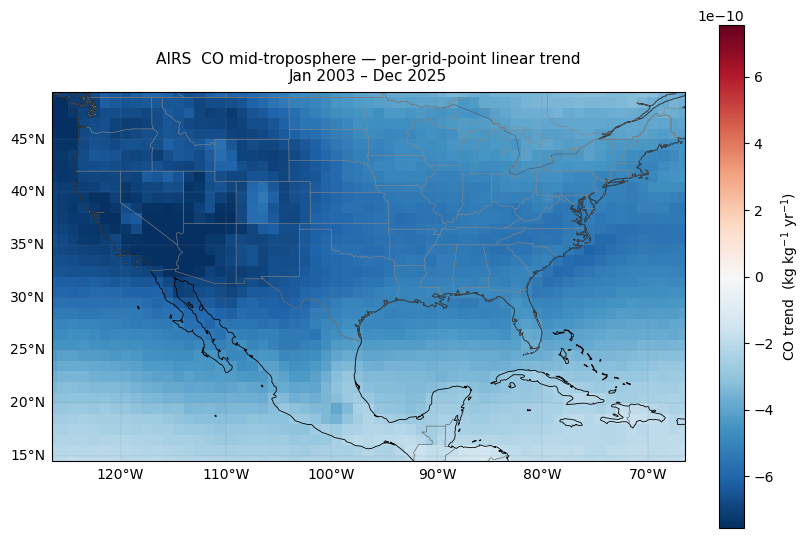

Saved -> D:\COCCON\Work\Figures\spatial_co_trend_slope_2003_2025.png


In [7]:
# ── Spatial map of the per-grid-point linear trend (slope) ───────────────────
# Reuses cube_da from the time-series cell (the reconstructed, gap-free maps),
# so the spatial trend and the time-series trend come from the SAME data.
# Fit y = a*x + b independently at every grid cell; slope a is kg/kg per year.
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# x in decimal years since the first month (same convention as the fit cell)
xg = (full_index - full_index[0]).days.values / 365.25
Y  = cube_da.values                                          # (time, lat, lon)

# vectorised least-squares slope per pixel:  a = Σ(x-x̄)(y-ȳ) / Σ(x-x̄)²
xg_c = xg - xg.mean()
Yc   = Y - Y.mean(axis=0, keepdims=True)
slope = np.tensordot(xg_c, Yc, axes=(0, 0)) / np.sum(xg_c**2)  # (lat, lon)

# pixels never observed in any month stay NaN
slope[np.all(np.isnan(Y), axis=0)] = np.nan

print(f"Per-pixel slope grid : {slope.shape}  (lat × lon)")
print(f"Slope range          : {np.nanmin(slope):.3e} – {np.nanmax(slope):.3e}  kg/kg/yr")
print(f"Domain-mean slope    : {np.nanmean(slope):.3e}  kg/kg/yr "
      f"(time-series fit was {a:.3e})")

# -- plot ----------------------------------------------------------------------
ext = [float(lons_g.min()), float(lons_g.max()),
       float(lats_g.min()), float(lats_g.max())]

# symmetric diverging colour scale about zero (trend up vs down)
vmax_s = np.nanpercentile(np.abs(slope), 98)

fig_s, ax_s = plt.subplots(
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)
ax_s.set_extent(ext, crs=ccrs.PlateCarree())
ax_s.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
ax_s.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
ax_s.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")

pcm = ax_s.pcolormesh(
    lons_g, lats_g, slope,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r", vmin=-vmax_s, vmax=vmax_s, shading="auto",
)
cb = fig_s.colorbar(pcm, ax=ax_s, orientation="vertical", shrink=0.85, pad=0.02)
cb.set_label("CO trend  (kg kg$^{-1}$ yr$^{-1}$)", fontsize=10)

gl = ax_s.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
gl.top_labels = gl.right_labels = False

ax_s.set_title(
    "AIRS  CO mid-troposphere — per-grid-point linear trend\n"
    f"{full_index[0].strftime('%b %Y')} – {full_index[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)

out_s = os.path.join(OUT_DIR, "spatial_co_trend_slope_2003_2025.png")
fig_s.savefig(out_s, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_s)
